In [4]:
!pip install scikit-learn seaborn matplotlib

  Using cached scikit_learn-1.7.2-cp312-cp312-manylinux2014_x86_64.manylinux_2_17_x86_64.whl.metadata (11 kB)
  Using cached joblib-1.5.2-py3-none-any.whl.metadata (5.6 kB)
  Using cached threadpoolctl-3.6.0-py3-none-any.whl.metadata (13 kB)
Using cached scikit_learn-1.7.2-cp312-cp312-manylinux2014_x86_64.manylinux_2_17_x86_64.whl (9.5 MB)
Using cached joblib-1.5.2-py3-none-any.whl (308 kB)
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 35.7/35.7 MB 34.5 MB/s  0:00:01m0:00:0100:01
Using cached threadpoolctl-3.6.0-py3-none-any.whl (18 kB)
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 4/4 [scikit-learn] [scikit-learn]


In [73]:
from sklearn.datasets import load_iris
import matplotlib.pyplot as plt
import seaborn as sns
import numpy as np
from sklearn import tree
import pandas as pd
import duckdb as dd

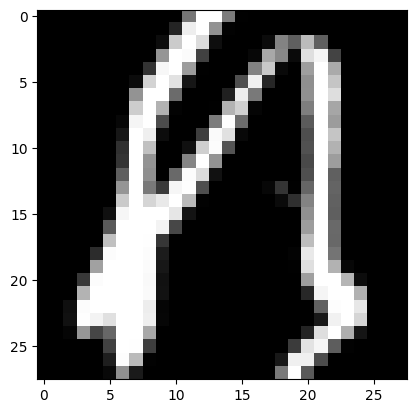

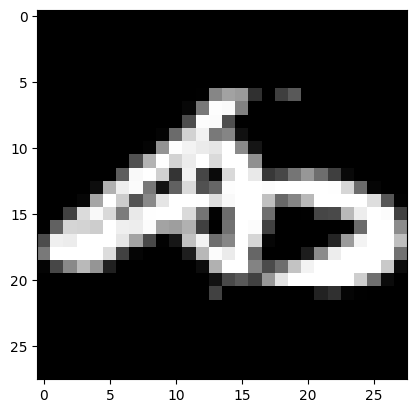

In [103]:
carpeta = 'Archivos/'
map_caracters =  pd.read_csv(carpeta + 'kuzushiji_full.csv')
class_caracters =  pd.read_csv(carpeta + 'kmnist_classmap_char.csv')

list_columns =  []
# Estoy colocando las columnas con los nombres pixel_i
for i in range(784):
    list_columns.append(f'pixel_{i+1}')
list_columns.append('label')
map_caracters.columns = list_columns


X = map_caracters.copy()
for i in range(2):
    img = np.array(X.iloc[i][:-1]).reshape((28,28))
    plt.imshow(img, cmap='gray')
    plt.show()


    

# Analisis de los datos Ej1:


2. DISTRIBUCIÓN DE CLASES
label
0    7000
1    7000
2    7000
3    7000
4    7000
5    7000
6    7000
7    7000
8    7000
9    7000
Name: count, dtype: int64


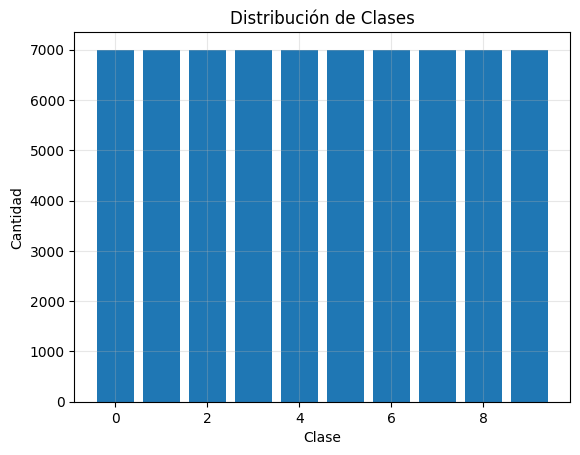

In [104]:

print("\n2. DISTRIBUCIÓN DE CLASES")
y = X['label']
distribucion_clases = y.value_counts().sort_index()
print(distribucion_clases)

plt.bar(distribucion_clases.index, distribucion_clases.values)
plt.xlabel('Clase')
plt.ylabel('Cantidad')
plt.title('Distribución de Clases')
plt.grid(True, alpha=0.3)

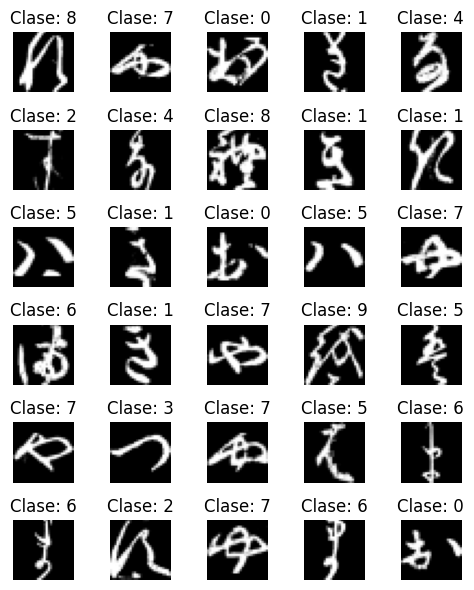

In [122]:
# Visualizar en grid de 3x3
filas = 6
columnas = 5

fig, axes = plt.subplots(filas, columnas, figsize=(columnas, filas))

for i in range(filas * columnas):
    if i < len(X):
        fila = i // columnas
        col = i % columnas
        
        img = np.array(X.iloc[i][:-1]).reshape((28, 28))
        label = X.iloc[i]['label']
        
        axes[fila, col].imshow(img, cmap='gray')
        axes[fila, col].set_title(f'Clase: {label}')
        axes[fila, col].axis('off')

plt.tight_layout()
plt.show()


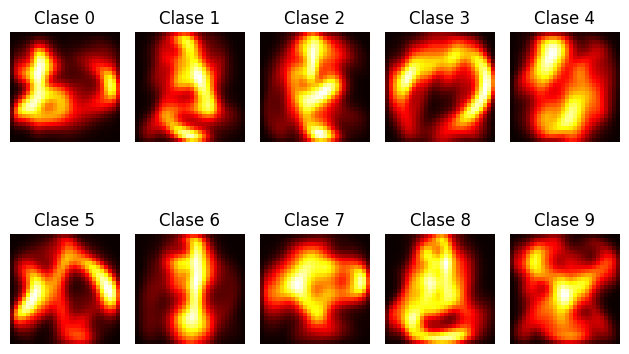

In [205]:
x = X.drop('label', axis = 1).values
y = X['label'].values

for j in range(10):
    mean_img =  x[y==j].mean(axis = 0).reshape(28,28)
    plt.subplot(2,5,j+1)
    plt.imshow(mean_img,cmap = 'hot')
    plt.title(f'Clase {j}')
    plt.axis('off')

plt.tight_layout()


(np.float64(-0.5), np.float64(27.5), np.float64(27.5), np.float64(-0.5))

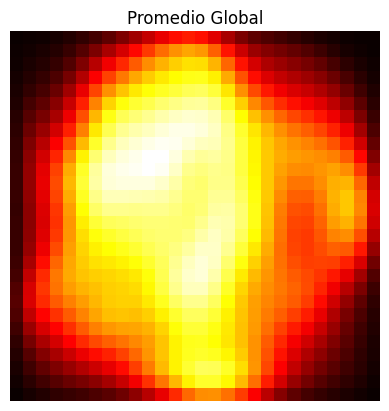

In [204]:
# Esto promedia TODAS las imágenes juntas
mean_global = x.mean(axis=0).reshape(28,28)  # ← Promedio de todo el dataset
plt.imshow(mean_global,cmap = 'hot')
plt.title(f'Promedio Global')
plt.axis('off') 

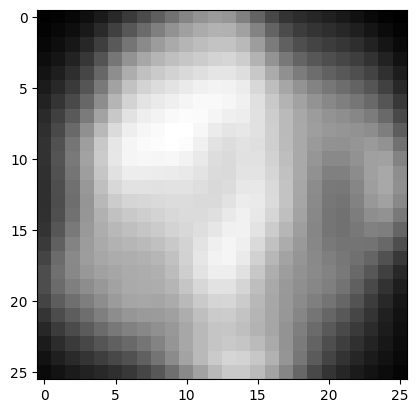

In [ ]:

def reshapear_imagen(img, n):
    if n == 0:
        return img
    else:
        img_2 =  img[n:-n]
        img_3 = np.array([fila[n:-n] for fila in img_2])
        return img_3
X = map_caracters.copy()

for i in range(1):
    mean_global = x.mean(axis=0).reshape(28,28)
    mean_global =   reshapear_imagen(mean_global, 1)
    plt.imshow(mean_global, cmap='gray')
    plt.show()


# Analisis 2

In [219]:

from sklearn.neighbors import KNeighborsClassifier
from sklearn.metrics import classification_report, confusion_matrix

kuzushiji_bi = map_caracters.loc[(map_caracters['label'] == 4) | (map_caracters['label'] == 5)]

n_muestras = 5000

muestras_train = kuzushiji_bi.groupby('label').sample(n=n_muestras).reset_index(drop=True)
muestras_test = kuzushiji_bi.loc[~kuzushiji_bi.index.isin(muestras_train.index)].reset_index(drop=True)

X_train = muestras_train.drop('label', axis=1).reset_index(drop=True)
y_train = muestras_train.loc[: , 'label'].reset_index(drop=True)

X_test = muestras_test.drop('label', axis=1)
y_test = muestras_test.loc[: , 'label']

#Ahora toca entrenar con distinta cantidad de atributos

clasificador = KNeighborsClassifier(n_neighbors=20)
clasificador.fit(X_train, y_train)

y_pred = clasificador.predict(X_test)

print(classification_report(y_test, y_pred))
confusion_matrix(y_test, y_pred)

              precision    recall  f1-score   support

           4       0.99      0.97      0.98      5939
           5       0.97      0.99      0.98      5992

    accuracy                           0.98     11931
   macro avg       0.98      0.98      0.98     11931
weighted avg       0.98      0.98      0.98     11931



array([[5782,  157],
       [  45, 5947]])

In [229]:


from sklearn.metrics import accuracy_score, precision_score, recall_score
#Creamos un for/loop para recorrer distinta cantidad de atributos, asi como seleccionar distintos atributos cada vez
report_list = []
for n in range(3,700,100):
    pres_4 = []
    pres_5 = []
    re_4 = []
    re_5 = []
    acc_rep = []
    for _ in range(0,5):
        X_train_n = X_train.sample(n = n, axis=1)

        atributos_seleccionados = [col for col in X_train_n if col in X_train]
        X_test_n = X_test[atributos_seleccionados]

        clasificador_n = KNeighborsClassifier(n_neighbors=10)

        clasificador_n.fit(X_train_n, y_train)

        y_pred_n = clasificador_n.predict(X_test_n)
        
        precision_4 = precision_score(pos_label=4, y_true=y_test, y_pred=y_pred_n)
        precision_5 = precision_score(pos_label=5, y_true=y_test, y_pred=y_pred_n)
        recall_4 = recall_score(pos_label=4, y_true=y_test, y_pred= y_pred_n)
        recall_5 = recall_score(pos_label=5, y_true=y_test, y_pred= y_pred_n)
        acc = accuracy_score(y_test, y_pred_n)

        pres_4.append(precision_4)
        pres_5.append(precision_5)
        re_4.append(recall_4)
        re_5.append(recall_5)
        acc_rep.append(acc)
    
    precision_clase_4 = np.average(pres_4)
    precision_clase_5 = np.average(pres_5)
    recall_clase_4 = np.average(re_4)
    recall_clase_5 = np.average(re_5)
    accuracy_n = np.average(acc_rep)

    report = {
        'presicion_4' : precision_clase_4,
        'precision_5' : precision_clase_5,
        'recall_4' : recall_clase_4,
        'recall_5' : recall_clase_5,
        'accuracy' : accuracy_n
    }

    report_list.append(report)


In [223]:
report_list

[{'presicion_4': np.float64(0.56401488408815),
  'precision_5': np.float64(0.6174786219293682),
  'recall_4': np.float64(0.9249368580569118),
  'recall_5': np.float64(0.27273030707610146),
  'accuracy': np.float64(0.597384963540357)},
 {'presicion_4': np.float64(0.8490269752832222),
  'precision_5': np.float64(0.8696860906209286),
  'recall_4': np.float64(0.8726721670314868),
  'recall_5': np.float64(0.8450267022696929),
  'accuracy': np.float64(0.8587880311792808)},
 {'presicion_4': np.float64(0.9327634034035654),
  'precision_5': np.float64(0.9167482436724825),
  'recall_4': np.float64(0.9142953359151372),
  'recall_5': np.float64(0.9346128170894525),
  'accuracy': np.float64(0.9244992037549242)},
 {'presicion_4': np.float64(0.9528243199183647),
  'precision_5': np.float64(0.9390092483419161),
  'recall_4': np.float64(0.9373968681596228),
  'recall_5': np.float64(0.9538718291054739),
  'accuracy': np.float64(0.945670941245495)},
 {'presicion_4': np.float64(0.9631524337578341),
  'pre

In [221]:

#Notar: habiendo agarrado anteriormente solo 10 atributos, al incrementar el k bajaba el accuracy, precision y recall

report_list_k = []

for k in [1, 3, 5, 10, 20, 30]:
    pres_4_k = []
    pres_5_k = []
    re_4_k = []
    re_5_k = []
    acc_rep_k = []
    
    for _ in range(0, 10):
        X_train_k = X_train.sample(n = 20, axis=1)

        atributos_selected = [col for col in X_train_k if col in X_train]
        X_test_k = X_test[atributos_selected]
    
        clasificador_k = KNeighborsClassifier(n_neighbors=k)
        clasificador_k.fit(X_train_k, y_train)

        y_pred_k = clasificador_k.predict(X_test_k)

        precision_4_k = precision_score(pos_label=4, y_true=y_test, y_pred=y_pred_k)
        precision_5_k = precision_score(pos_label=5, y_true=y_test, y_pred=y_pred_k)
        recall_4_k = recall_score(pos_label=4, y_true=y_test, y_pred=y_pred_k)
        recall_5_k = recall_score(pos_label=4, y_true=y_test, y_pred=y_pred_k)
        acc_k = accuracy_score(y_test, y_pred_k)

        pres_4_k.append(precision_4_k)
        pres_5_k.append(precision_5_k)
        re_4_k.append(recall_4_k)
        re_5_k.append(recall_5_k)
        acc_rep_k.append(acc_k)
    
    precision_clase_4_k = np.average(pres_4_k)
    precision_clase_5_k = np.average(pres_5_k)
    recall_clase_4_k = np.average(re_4_k)
    recall_clase_5_k = np.average(re_5_k)
    accuracy_k = np.average(acc_rep_k)

    report_k = {k : {
        'presicion_4' : precision_clase_4_k,
        'precision_5' : precision_clase_5_k,
        'recall_4' : recall_clase_4_k,
        'recall_5' : recall_clase_5_k,
        'accuracy' : accuracy_k
    }}

    report_list_k.append(report_k)


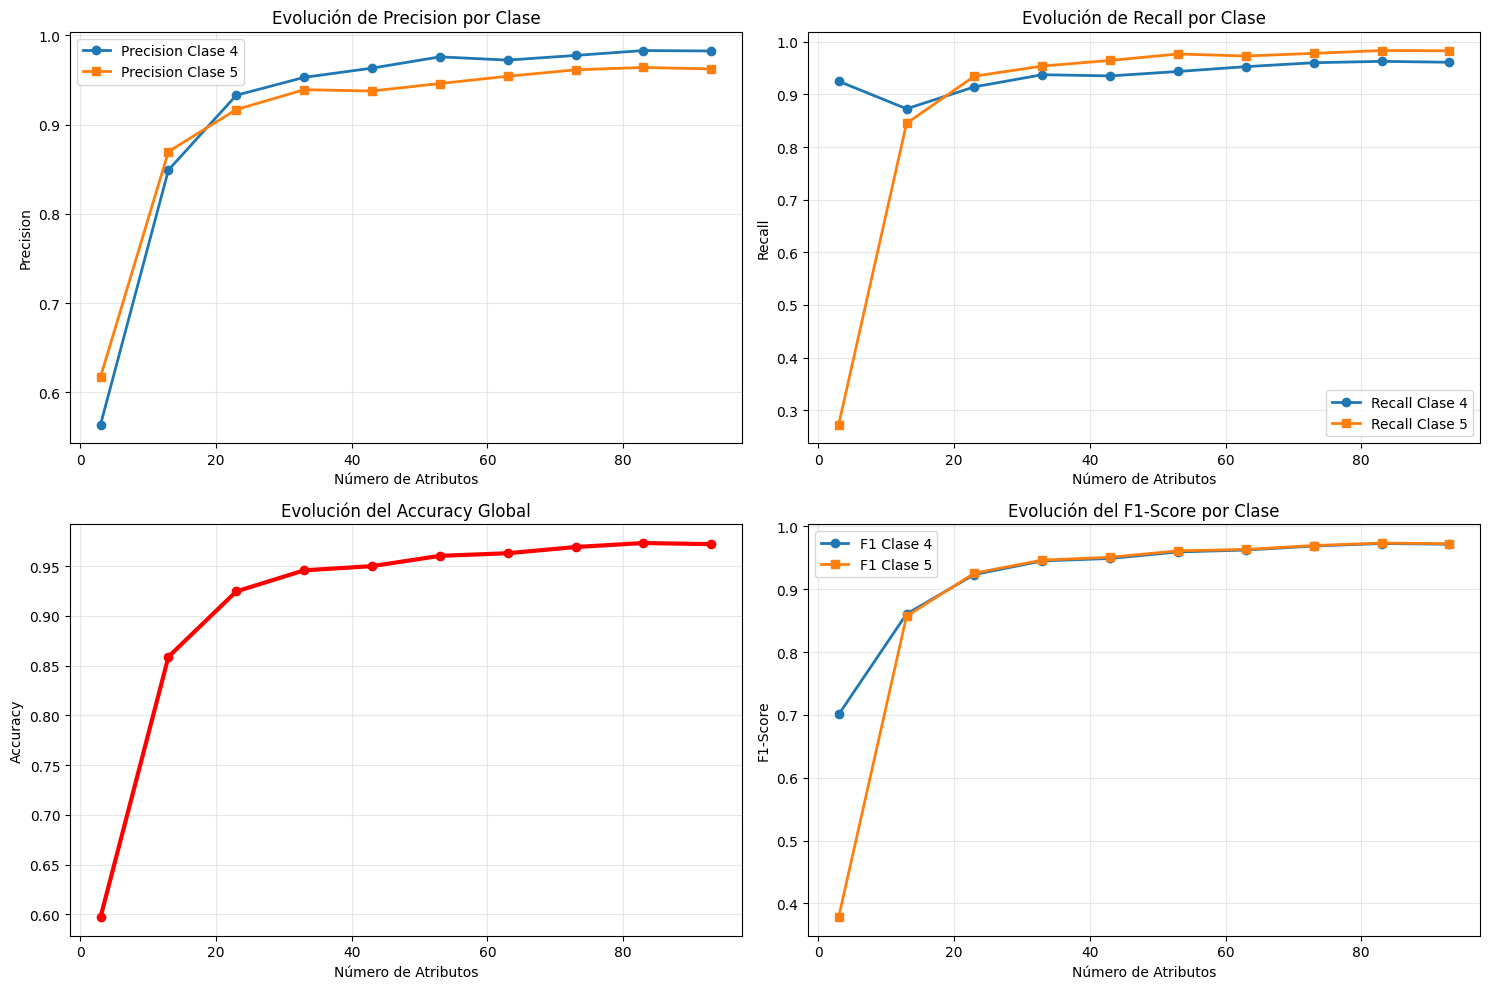

In [ ]:
import matplotlib.pyplot as plt
import pandas as pd
import numpy as np

# Convertir results a DataFrame
df_results = pd.DataFrame(report_list)
df_results['n_atributos'] = range(3, 100, 10)

# Crear subplots
fig, axes = plt.subplots(2, 2, figsize=(15, 10))

# Precision por clase
axes[0,0].plot(df_results['n_atributos'], df_results['presicion_4'], 
               'o-', label='Precision Clase 4', linewidth=2)
axes[0,0].plot(df_results['n_atributos'], df_results['precision_5'], 
               's-', label='Precision Clase 5', linewidth=2)
axes[0,0].set_xlabel('Número de Atributos')
axes[0,0].set_ylabel('Precision')
axes[0,0].set_title('Evolución de Precision por Clase')
axes[0,0].legend()
axes[0,0].grid(True, alpha=0.3)

# Recall por clase
axes[0,1].plot(df_results['n_atributos'], df_results['recall_4'], 
               'o-', label='Recall Clase 4', linewidth=2)
axes[0,1].plot(df_results['n_atributos'], df_results['recall_5'], 
               's-', label='Recall Clase 5', linewidth=2)
axes[0,1].set_xlabel('Número de Atributos')
axes[0,1].set_ylabel('Recall')
axes[0,1].set_title('Evolución de Recall por Clase')
axes[0,1].legend()
axes[0,1].grid(True, alpha=0.3)

# Accuracy global
axes[1,0].plot(df_results['n_atributos'], df_results['accuracy'], 
               'o-', color='red', linewidth=3, label='Accuracy')
axes[1,0].set_xlabel('Número de Atributos')
axes[1,0].set_ylabel('Accuracy')
axes[1,0].set_title('Evolución del Accuracy Global')
axes[1,0].grid(True, alpha=0.3)

# F1-Score por clase (calculado)
df_results['f1_4'] = 2 * (df_results['presicion_4'] * df_results['recall_4']) / (df_results['presicion_4'] + df_results['recall_4'])
df_results['f1_5'] = 2 * (df_results['precision_5'] * df_results['recall_5']) / (df_results['precision_5'] + df_results['recall_5'])

axes[1,1].plot(df_results['n_atributos'], df_results['f1_4'], 
               'o-', label='F1 Clase 4', linewidth=2)
axes[1,1].plot(df_results['n_atributos'], df_results['f1_5'], 
               's-', label='F1 Clase 5', linewidth=2)
axes[1,1].set_xlabel('Número de Atributos')
axes[1,1].set_ylabel('F1-Score')
axes[1,1].set_title('Evolución del F1-Score por Clase')
axes[1,1].legend()
axes[1,1].grid(True, alpha=0.3)

plt.tight_layout()
plt.show()

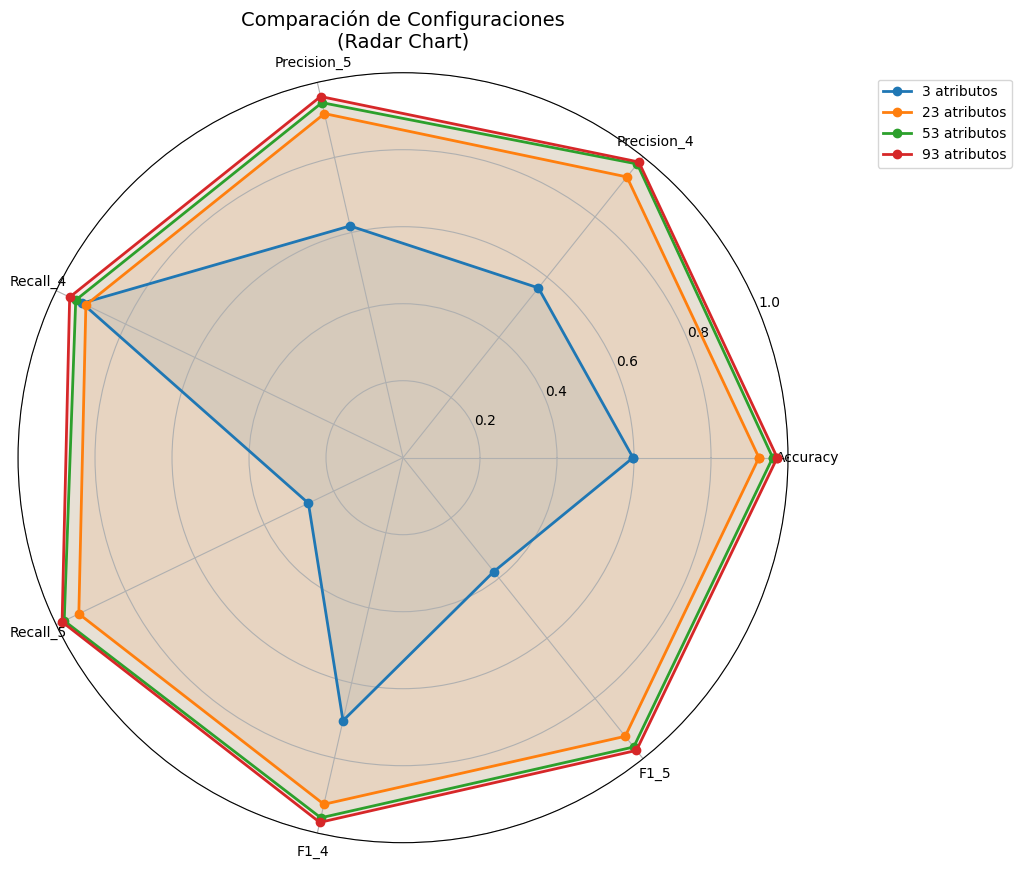

In [226]:
from math import pi

def create_radar_chart(df, n_atributos_list):
    categories = ['Accuracy', 'Precision_4', 'Precision_5', 
                  'Recall_4', 'Recall_5', 'F1_4', 'F1_5']
    
    fig = plt.figure(figsize=(10, 10))
    ax = fig.add_subplot(111, polar=True)
    
    angles = [n / float(len(categories)) * 2 * pi for n in range(len(categories))]
    angles += angles[:1]  # Cerrar el círculo
    
    for n in n_atributos_list:
        values = df[df['n_atributos'] == n].iloc[0]
        radar_values = [
            values['accuracy'],
            values['presicion_4'],
            values['precision_5'],
            values['recall_4'], 
            values['recall_5'],
            values['f1_4'],
            values['f1_5']
        ]
        radar_values += radar_values[:1]
        
        ax.plot(angles, radar_values, 'o-', linewidth=2, label=f'{n} atributos')
        ax.fill(angles, radar_values, alpha=0.1)
    
    ax.set_xticks(angles[:-1])
    ax.set_xticklabels(categories)
    ax.set_ylim(0, 1)
    plt.title('Comparación de Configuraciones\n(Radar Chart)', size=14)
    plt.legend(loc='upper right', bbox_to_anchor=(1.3, 1.0))
    plt.show()

# Usar solo algunas configuraciones para claridad
configs_comparar = [3, 23, 53, 93]  # Pocos, intermedio, muchos atributos
create_radar_chart(df_results, configs_comparar)

# Analisis 3

In [230]:
from sklearn.tree import DecisionTreeClassifier
from sklearn.model_selection import cross_val_score

#map_caracters

muestras_train_tree = map_caracters.groupby('label').sample(n=n_muestras)
muestras_val_tree = map_caracters.loc[~map_caracters.index.isin(muestras_train_tree)]

X_train_tree = muestras_train_tree.drop('label', axis=1).reset_index(drop=True)
y_train_tree = muestras_train_tree.loc[:, 'label'].reset_index(drop=True)

X_val_tree = muestras_val_tree.drop('label', axis=1).reset_index(drop=True)
y_val_tree = muestras_val_tree.loc[:, 'label'].reset_index(drop=True)

metrics = []
for i in range(1,11):
    dtc = DecisionTreeClassifier(max_depth=i)
    metricas = cross_val_score(dtc, X_train_tree, y_train_tree, cv=5)
    metrics.append(metricas)

print(metrics)

KeyboardInterrupt: 